In [2]:
!pip install tensorflow matplotlib numpy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.4/351.2 MB 11.1 MB/s eta 0:00:32
    --------------------------------------- 4.7/351.2 MB 11.4 MB/s eta 0:00:31
    --------------------------------------- 7.3/351.2 MB 11.5 MB/s eta 0:00:30
   - -------------------------------------- 10.0/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 12.3/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 14.7/351.2 MB 11.6 MB/s eta 0:00:29
   - -------------------------------------- 17.0/351.2 MB 11.6 MB/s eta 0:00:29
   -- ------------------------------------- 18.9/351.2 MB 11.4 MB/s eta 0:00:30
   -- ------------------------------------- 20.7/351.2 MB 11.1 MB/s eta 0:00:30
   -- ------------------------------------- 23.1/351.2 MB 11.1 MB/s eta 0:00:30
   -- ------------------------------------- 25.4/351.2 MB 11.1 MB/s eta 0:00:30
   --- ------------------------------------ 27.8/351

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


## Import Required Libraries

# CNN Sample Problems: Convolution & Max Pooling

Practice problems demonstrating convolutional neural networks with practical Python implementations.

# Problem 1: Understanding Convolution & Max Pooling Operations

**Objective**: Learn how convolution and max pooling work by implementing them from scratch with NumPy

## Part 1a: Basic Convolution Operation

In [4]:
# Create a simple 5x5 input image
input_image = np.array([
    [1, 0, 2, 1, 0],
    [0, 3, 1, 2, 1],
    [2, 1, 0, 1, 2],
    [1, 2, 3, 0, 1],
    [0, 1, 2, 1, 0]
], dtype=float)

# Define a 3x3 filter (kernel)
kernel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=float)

print("Input Image (5x5):")
print(input_image)
print("\nKernel/Filter (3x3):")
print(kernel)

Input Image (5x5):
[[1. 0. 2. 1. 0.]
 [0. 3. 1. 2. 1.]
 [2. 1. 0. 1. 2.]
 [1. 2. 3. 0. 1.]
 [0. 1. 2. 1. 0.]]

Kernel/Filter (3x3):
[[ 1.  0. -1.]
 [ 2.  0. -2.]
 [ 1.  0. -1.]]


In [5]:
# Implement 2D Convolution from scratch
def convolution_2d(image, kernel, stride=1, padding=0):
    """
    Perform 2D convolution operation
    
    Args:
        image: Input image (2D array)
        kernel: Convolution kernel/filter (2D array)
        stride: Step size of kernel movement
        padding: Zero padding around image
    
    Returns:
        output: Convolved feature map
    """
    
    # Add padding if needed
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)
    
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    
    # Calculate output dimensions
    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1
    
    # Initialize output
    output = np.zeros((out_h, out_w))
    
    # Perform convolution
    for i in range(0, img_h - k_h + 1, stride):
        for j in range(0, img_w - k_w + 1, stride):
            # Extract region of interest
            region = image[i:i+k_h, j:j+k_w]
            # Element-wise multiplication and sum
            output[i//stride, j//stride] = np.sum(region * kernel)
    
    return output

# Apply convolution
feature_map = convolution_2d(input_image, kernel, stride=1, padding=0)

print("Feature Map (output of convolution):")
print(feature_map)
print(f"\nOutput shape: {feature_map.shape}")
print(f"Input shape: {input_image.shape}, Kernel shape: {kernel.shape}")

Feature Map (output of convolution):
[[-1.  1.  0.]
 [ 1.  3. -2.]
 [-4.  4.  4.]]

Output shape: (3, 3)
Input shape: (5, 5), Kernel shape: (3, 3)


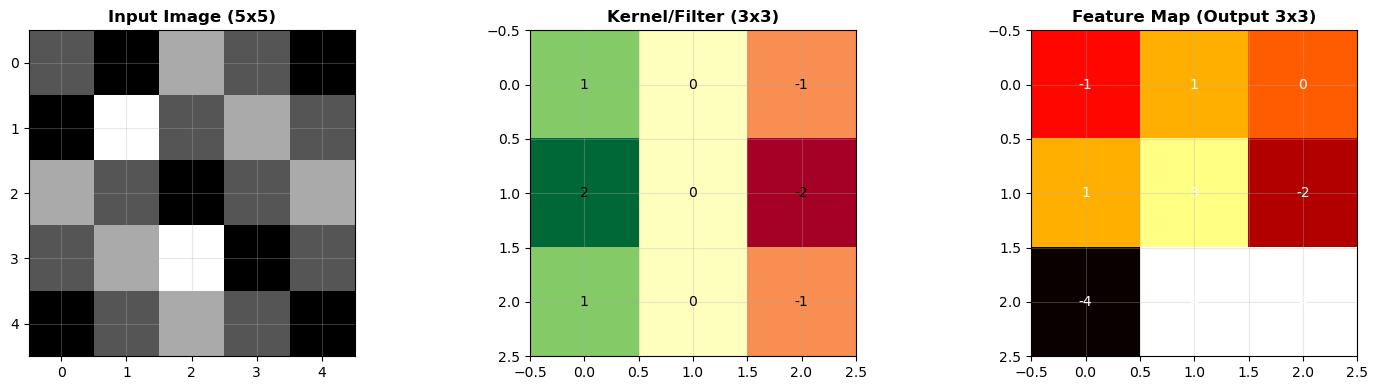

Convolution demonstration complete!


In [6]:
# Visualize convolution operation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Input image
axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Input Image (5x5)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Kernel
axes[1].imshow(kernel, cmap='RdYlGn')
axes[1].set_title('Kernel/Filter (3x3)', fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{kernel[i, j]:.0f}', ha='center', va='center', color='black')
axes[1].grid(True, alpha=0.3)

# Output feature map
axes[2].imshow(feature_map, cmap='hot')
axes[2].set_title('Feature Map (Output 3x3)', fontsize=12, fontweight='bold')
for i in range(feature_map.shape[0]):
    for j in range(feature_map.shape[1]):
        axes[2].text(j, i, f'{feature_map[i, j]:.0f}', ha='center', va='center', color='white', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Convolution demonstration complete!")

## Part 1b: Max Pooling Operation

In [7]:
# Implement Max Pooling from scratch
def max_pooling_2d(image, pool_size=2, stride=None):
    """
    Perform 2D max pooling operation
    
    Args:
        image: Input feature map (2D array)
        pool_size: Size of pooling window (default: 2x2)
        stride: Step size of pooling (default: pool_size)
    
    Returns:
        output: Pooled feature map
    """
    
    if stride is None:
        stride = pool_size
    
    img_h, img_w = image.shape
    
    # Calculate output dimensions
    out_h = (img_h - pool_size) // stride + 1
    out_w = (img_w - pool_size) // stride + 1
    
    # Initialize output
    output = np.zeros((out_h, out_w))
    
    # Perform max pooling
    for i in range(0, img_h - pool_size + 1, stride):
        for j in range(0, img_w - pool_size + 1, stride):
            # Extract region and take maximum
            region = image[i:i+pool_size, j:j+pool_size]
            output[i//stride, j//stride] = np.max(region)
    
    return output

# Create a 4x4 sample feature map
sample_feature_map = np.array([
    [2.1, 1.5, 3.2, 0.8],
    [1.3, 2.7, 1.9, 2.2],
    [3.5, 0.9, 2.1, 1.6],
    [2.0, 1.2, 3.0, 2.5]
], dtype=float)

print("Sample Feature Map (4x4):")
print(sample_feature_map)

# Apply max pooling with 2x2 window and stride 2
pooled = max_pooling_2d(sample_feature_map, pool_size=2, stride=2)

print("\nAfter Max Pooling (2x2):")
print(pooled)
print(f"\nDimension reduction: {sample_feature_map.shape} → {pooled.shape}")

Sample Feature Map (4x4):
[[2.1 1.5 3.2 0.8]
 [1.3 2.7 1.9 2.2]
 [3.5 0.9 2.1 1.6]
 [2.  1.2 3.  2.5]]

After Max Pooling (2x2):
[[2.7 3.2]
 [3.5 3. ]]

Dimension reduction: (4, 4) → (2, 2)


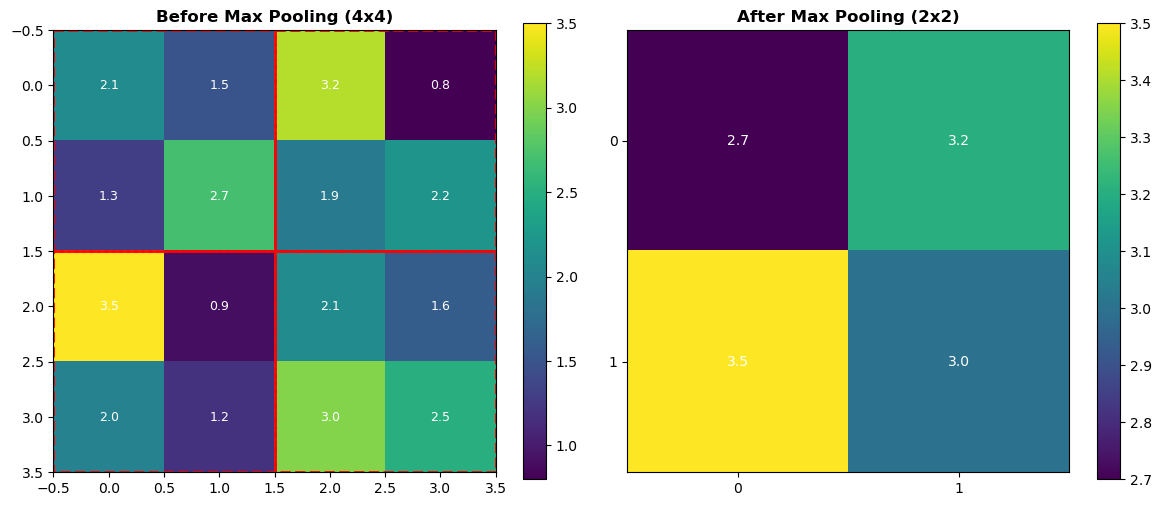

Max pooling reduces spatial dimensions while preserving important features!


In [8]:
# Visualize max pooling operation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Feature map before pooling
im0 = axes[0].imshow(sample_feature_map, cmap='viridis')
axes[0].set_title('Before Max Pooling (4x4)', fontsize=12, fontweight='bold')
for i in range(sample_feature_map.shape[0]):
    for j in range(sample_feature_map.shape[1]):
        axes[0].text(j, i, f'{sample_feature_map[i, j]:.1f}', 
                    ha='center', va='center', color='white', fontsize=9)
# Add pooling windows
for i in range(0, 4, 2):
    for j in range(0, 4, 2):
        rect = Rectangle((j-0.5, i-0.5), 2, 2, linewidth=2, 
                        edgecolor='red', facecolor='none', linestyle='--')
        axes[0].add_patch(rect)
plt.colorbar(im0, ax=axes[0])

# Feature map after pooling
im1 = axes[1].imshow(pooled, cmap='viridis')
axes[1].set_title('After Max Pooling (2x2)', fontsize=12, fontweight='bold')
for i in range(pooled.shape[0]):
    for j in range(pooled.shape[1]):
        axes[1].text(j, i, f'{pooled[i, j]:.1f}', 
                    ha='center', va='center', color='white', fontsize=10)
plt.colorbar(im1, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])

plt.tight_layout()
plt.show()

print("Max pooling reduces spatial dimensions while preserving important features!")

# Problem 2: Multi-Layer CNN for MNIST Digit Classification

**Objective**: Build and train a CNN with multiple convolutional and max pooling layers to classify handwritten digits

## Step 1: Load and Prepare MNIST Dataset

In [10]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Original shapes:")
print(f"  Training images: {X_train.shape}")
print(f"  Training labels: {y_train.shape}")
print(f"  Test images: {X_test.shape}")
print(f"  Test labels: {y_test.shape}")

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape for CNN (add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"\nAfter preprocessing:")
print(f"  Training images: {X_train.shape}")
print(f"  Training labels: {y_train.shape}")
print(f"  Pixel value range: [{X_train.min():.2f}, {X_train.max():.2f}]")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Original shapes:
  Training images: (60000, 28, 28)
  Training labels: (60000,)
  Test images: (10000, 28, 28)
  Test labels: (10000,)

After preprocessing:
  Training images: (60000, 28, 28, 1)
  Training labels: (60000, 10)
  Pixel value range: [0.00, 1.00]


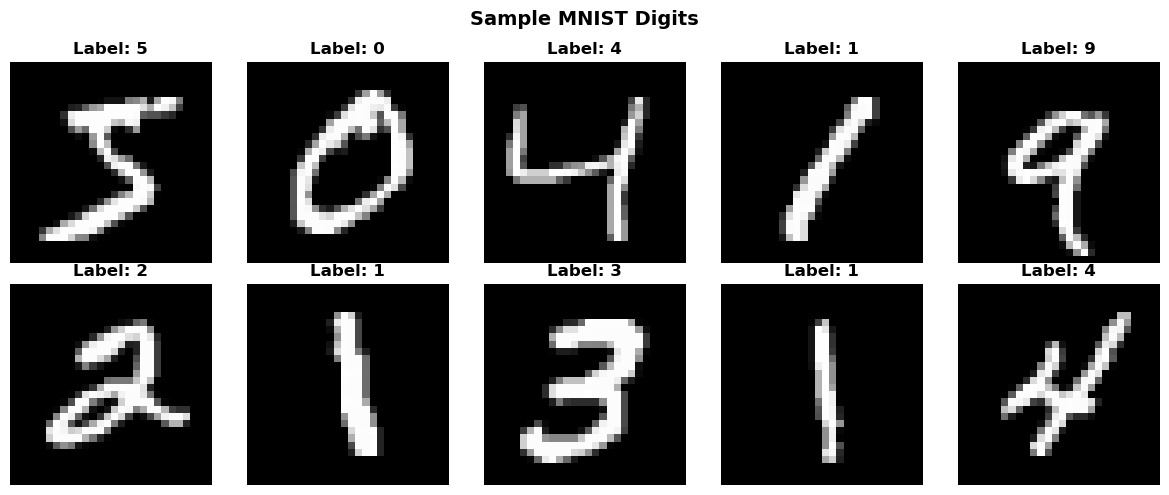

In [11]:
# Visualize sample MNIST digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {np.argmax(y_train[i])}', fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample MNIST Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 2: Build Multi-Layer CNN Architecture

Architecture:
- Conv2D: 32 filters, 3×3 kernel
- MaxPool2D: 2×2 window
- Conv2D: 64 filters, 3×3 kernel
- MaxPool2D: 2×2 window
- Flatten layer
- Dense: 128 units, ReLU
- Dense (output): 10 units, Softmax

In [12]:
# Build CNN model
model = models.Sequential([
    # First Conv block: Conv + MaxPool
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Second Conv block: Conv + MaxPool
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Display model architecture
model.summary()

print("\n" + "="*60)
print("ARCHITECTURE EXPLANATION:")
print("="*60)
print("""
Layer 1: Conv2D(32 filters, 3×3) + MaxPool(2×2)
  Input:  28×28×1 → Conv output: 28×28×32 → Pool output: 14×14×32
  
Layer 2: Conv2D(64 filters, 3×3) + MaxPool(2×2)
  Input:  14×14×32 → Conv output: 14×14×64 → Pool output: 7×7×64
  
Layer 3: Flatten
  Input:  7×7×64 = 3136 units → Output: 1D vector of 3136 values
  
Layer 4: Dense(128) with ReLU activation
  Extracts high-level features from flattened Conv outputs
  
Layer 5: Dense(10) with Softmax
  Outputs probabilities for 10 digit classes (0-9)
""")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)


ARCHITECTURE EXPLANATION:

Layer 1: Conv2D(32 filters, 3×3) + MaxPool(2×2)
  Input:  28×28×1 → Conv output: 28×28×32 → Pool output: 14×14×32

Layer 2: Conv2D(64 filters, 3×3) + MaxPool(2×2)
  Input:  14×14×32 → Conv output: 14×14×64 → Pool output: 7×7×64

Layer 3: Flatten
  Input:  7×7×64 = 3136 units → Output: 1D vector of 3136 values

Layer 4: Dense(128) with ReLU activation
  Extracts high-level features from flattened Conv outputs

Layer 5: Dense(10) with Softmax
  Outputs probabilities for 10 digit classes (0-9)



## Step 3: Compile and Train the Model

In [13]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model (using subset of data for faster execution)
print("Training CNN model on MNIST dataset...")
print("Using 10,000 training samples for demonstration...")

history = model.fit(
    X_train[:10000], y_train[:10000],
    batch_size=128,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

Training CNN model on MNIST dataset...
Using 10,000 training samples for demonstration...
Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7031 - loss: 0.9240 - val_accuracy: 0.9230 - val_loss: 0.2675
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9076 - loss: 0.3091 - val_accuracy: 0.9540 - val_loss: 0.1562
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9416 - loss: 0.1998 - val_accuracy: 0.9570 - val_loss: 0.1213
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9568 - loss: 0.1505 - val_accuracy: 0.9750 - val_loss: 0.0890
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9616 - loss: 0.1266 - val_accuracy: 0.9780 - val_loss: 0.0794


## Step 4: Evaluate Model Performance

Test Loss: 0.1135
Test Accuracy: 0.9640


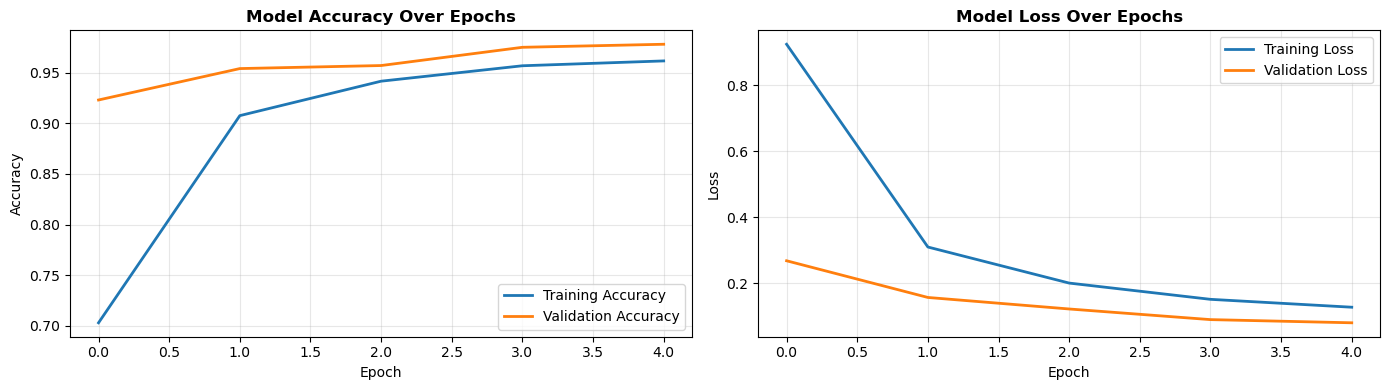

In [14]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test[:2000], y_test[:2000], verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 5: Visualize Model Predictions

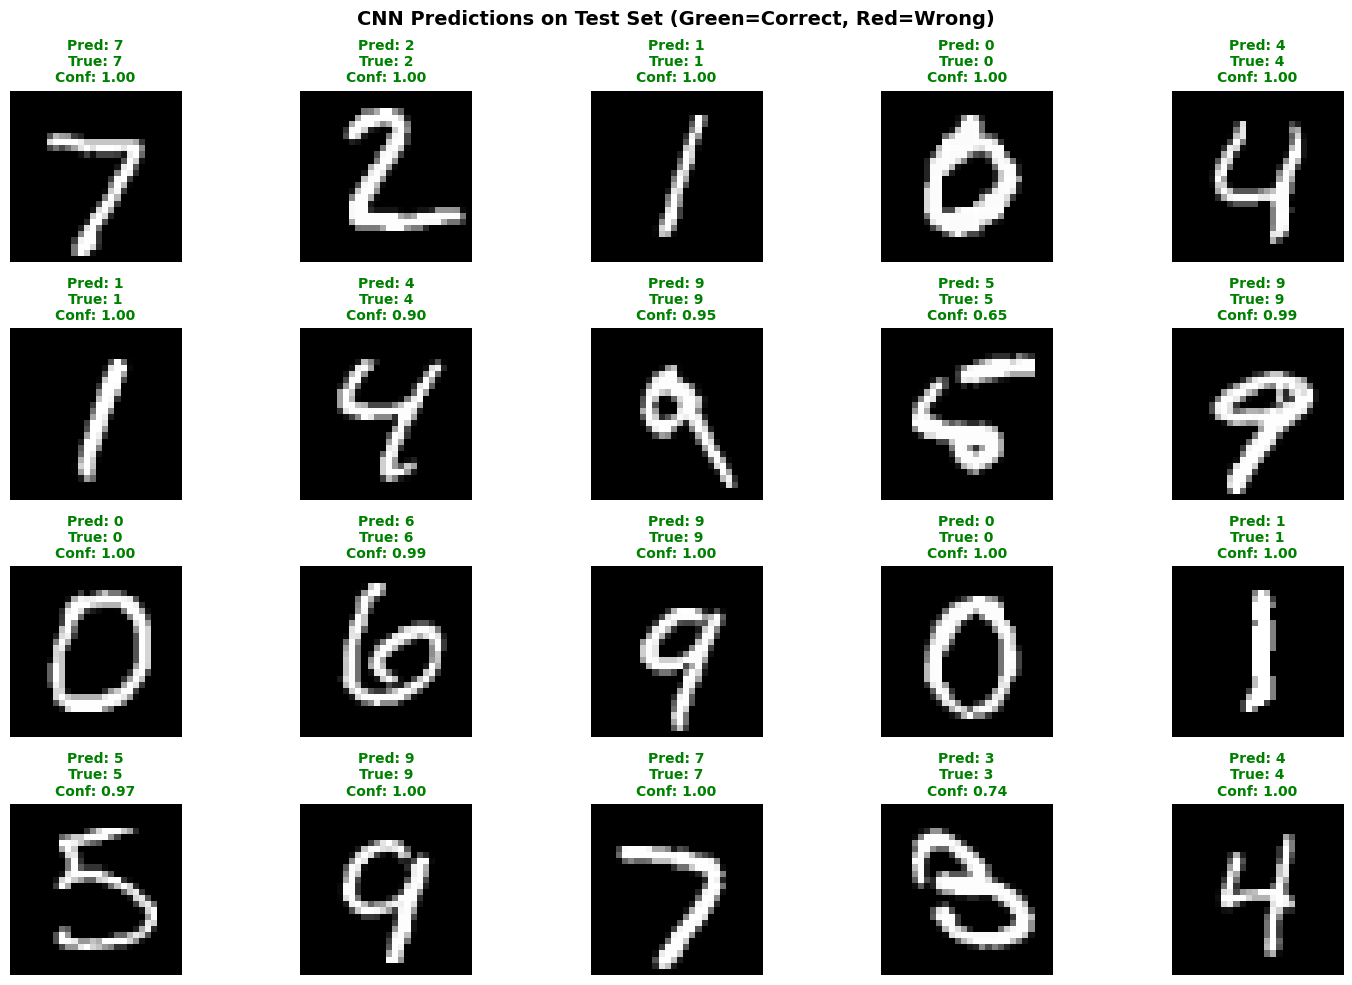

In [15]:
# Make predictions on test set
predictions = model.predict(X_test[:20], verbose=0)

# Visualize predictions
fig, axes = plt.subplots(4, 5, figsize=(15, 10))

for idx, ax in enumerate(axes.flat):
    # Display image
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    
    # Get prediction
    pred_class = np.argmax(predictions[idx])
    true_class = np.argmax(y_test[idx])
    confidence = predictions[idx][pred_class]
    
    # Color: green if correct, red if incorrect
    color = 'green' if pred_class == true_class else 'red'
    
    # Title
    title = f"Pred: {pred_class}\nTrue: {true_class}\nConf: {confidence:.2f}"
    ax.set_title(title, fontweight='bold', color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('CNN Predictions on Test Set (Green=Correct, Red=Wrong)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Summary: Key Takeaways

### Problem 1: Manual Implementation
- **Convolution**: Slides a filter across the image, computing element-wise multiplications
- **Max Pooling**: Takes maximum value from non-overlapping windows to downsample features
- Output dimensions follow: $\text{Output} = \frac{\text{Input} - \text{Kernel} + 2 \times \text{Padding}}{\text{Stride}} + 1$

### Problem 2: CNN Architecture for MNIST
- **Conv Layer 1**: 32 filters extract low-level features (edges, textures)
- **MaxPool 1**: Reduces 28×28 → 14×14 while preserving important information
- **Conv Layer 2**: 64 filters extract higher-level features
- **MaxPool 2**: Further reduces 14×14 → 7×7
- **Dense Layers**: Combine features for final classification

### Why Conv + MaxPool Works
1. **Feature Extraction**: Conv filters learn to detect important patterns
2. **Dimensionality Reduction**: MaxPool reduces computation and prevents overfitting
3. **Parameter Efficiency**: Shared weights reduce total parameters vs fully connected
4. **Translation Invariance**: MaxPool helps model generalize across image positions